## Extrae en línea la base de datos “Iris.csv” de la siguiente liga y agrégala a un DataFrame en Python. 

In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IRIS = pd.read_csv("iris.csv")
IRIS

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


## Efectúa un análisis de componentes principales (PCA) para los datos de la base de Iris y comenta sobre cuál sería el grado de explicación de la varianza que tendría al utilizar los dos primeros componentes.

In [7]:
IRIS_Var = IRIS.iloc[: , :-1]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(IRIS_Var)
scaled_data

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

# Entrenamiento del modelo PCA con escalado de los datos 
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(IRIS_Var)

# Se extrae el modelo entrendao del pipeline
modelo_pca = pca_pipe.named_steps["pca"]

# Porcentaje la varianza explicada por cada nuevo componente
print("Porcentaje de varianza explicada por componentes")
print(modelo_pca.explained_variance_ratio_)

Porcentaje de varianza explicada por componentes
[0.72962445 0.22850762 0.03668922 0.00517871]


### De acuerdo con lo mostrado en el analisis, las dos columnas que serian Sepal Lenght y sepal Width son las que tienen mayor "varianza" con un 72.9% y 22.8% respectivamente.

## Grafica tanto el mapa de observaciones como el de factores asociados a esta base de datos.

¿Qué puede concluir al compararlos? 

Corrobore sus conclusiones al revisar casos específicos en su Data Frame.

In [9]:
# Proyecciones de los componenetes
Proy = np.dot(modelo_pca.components_, scaled_data.T)
Proy = pd.DataFrame(Proy, index = ["PC1", "PC2", "PC3", "PC4"])
Proy = Proy.transpose().set_index(IRIS.index)
Proy

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


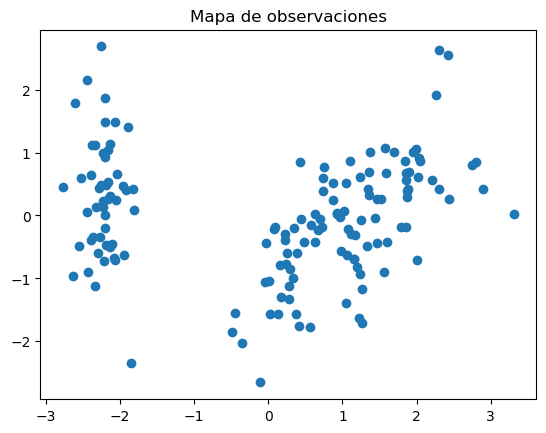

In [19]:
x_Mapa = Proy.iloc[:,0]
y_Mapa = Proy.iloc[:,1]
x_Mapa = x_Mapa.to_numpy()
y_Mapa = y_Mapa.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")
ax.scatter(x_Mapa,y_Mapa)

#for i, txt in enumerate(z):
#    ax.annotate(txt, (x[i], y[i]))

In [20]:
Proyeccion2 = pd.DataFrame(data = modelo_pca.components_, 
                            columns=  IRIS_Var.columns,
                            index = ["PC1", "PC2", "PC3", "PC4"])
Proyeccion2 = Proyeccion2.iloc[0:2,:]
Proyeccion2 = Proyeccion2.T
Proyeccion2

,PC1,PC2
sepal.length,0.521066,0.377418
sepal.width,-0.269347,0.923296
petal.length,0.580413,0.024492
petal.width,0.564857,0.066942


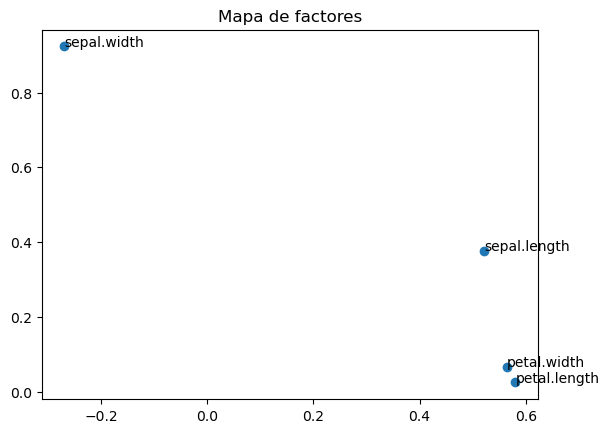

In [21]:
x_Fact = Proyeccion2.iloc[:,0]
y_Fact = Proyeccion2.iloc[:,1]
z_Fact = Proyeccion2.index
x_Fact = x_Fact.to_numpy()
y_Fact = y_Fact.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de factores")
ax.scatter(x_Fact,y_Fact)

for i, txt in enumerate(z):
    ax.annotate(txt, (x_Fact[i], y_Fact[i]))

### ¿Qué puede concluir al compararlos? 
Hay 2 conjuntos principales que toman mas del 90% de la varianza, el ancho (width) y largo (length) del sepal, estos se pueden ver como estan divididos, y que los petalos estan practicamente excluidos en los conjuntos


### Corrobore sus conclusiones al revisar casos específicos en su Data Frame.

In [25]:
IRIS.head(10)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


Al revisar los datos iniciales podemos ver que el Sépalo posee más variaciones, pero que tiene relación tanto el ancho como el largo.
Pero por parte del pétalo este no cambia mucho e incluso con cambios en la longitud, el ancho del pétalo aparenta tener poca variación (según los 10 datos tomados)

### Conclusiones

En conclusión, esto demuestra cómo es que las variables pueden tener más "peso" o varianza que otras, y como estos conjuntos tienen distinta predisposición a estar en otros grupos.
Para la gráfica de observaciones no se conservaron las etiquetas dado que no tienen particularidad, o índice, son únicamente números.